<a href="https://colab.research.google.com/github/ailingomezromay/Grupo-4--TP-BigData-Burnout/blob/main/TP_Grupo%204_BigData_Burnout.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP Final - Big Data y MLOps

Predicción de riesgo de burnout en empleados del sector tecnológico

# Grupo 4
Ailin Gomez Romay  
Carlos Lazzarino  
Victoria Reppucci  
Vanessa Vidal

# 1. Introducción



## Objetivo del trabajo

El objetivo de este trabajo es desarrollar un modelo de Machine Learning capaz de predecir el riesgo de burnout en empleados del sector tecnológico, a partir de variables demográficas, laborales y relacionadas con la salud mental.

## Dataset

El dataset fue obtenido de Kaggle ( https://www.kaggle.com/datasets/suhanigupta04/employee-mental-health-and-burnout-dataset ).

Contiene aproximadamente 150.000 registros sintéticos de empleados del sector tecnológico, con 25 variables que incluyen información demográfica, condiciones laborales e indicadores de salud mental.

El volumen del dataset justifica el uso de PySpark como framework de procesamiento distribuido. Además, las variables disponibles tienen una interpretación intuitiva y relevante para el problema: horas trabajadas, nivel de estrés, calidad de sueño, entre otras.

## Problema a resolver

Se busca identificar qué empleados presentan mayor riesgo de burnout a partir de variables observables. Este tipo de análisis puede resultar de utilidad para áreas de Recursos Humanos y bienestar organizacional, ya que permite anticipar situaciones de riesgo y tomar decisiones preventivas de manera informada.

# 2. Librerías e imports

IMPORTANTE: Instalar los requirements previo a la ejecución de la notebook. Los pasos están detallados en el README del proyecto

In [15]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import optuna

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression as SklearnLR
from sklearn.ensemble import RandomForestClassifier as SklearnRF
from sklearn.model_selection import train_test_split

import mlflow
import mlflow.spark
from mlflow.tracking import MlflowClient
mlflow.set_tracking_uri("sqlite:///mlflow.db")
import shap

# Suprimir logs verbose de Optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


# 3. Carga del dataset

Una vez cargado el dataset, se realiza una inspección inicial para verificar la cantidad de registros y variables disponibles.

In [5]:
root_path = os.path.abspath(os.path.join(os.getcwd(), ".."))
data_path = os.path.join(root_path, "data", "tech_mental_health_burnout.csv")
df = pd.read_csv(data_path)

print(f'Dimensiones del dataset: {df.shape[0]:,} filas x {df.shape[1]} columnas')
df.head()

Dimensiones del dataset: 150,000 filas x 25 columnas


,age,gender,job_role,experience_years,company_size,work_mode,work_hours_per_week,overtime_hours,meetings_per_day,deadlines_missed,...,screen_time_hours,caffeine_intake,social_support_score,has_therapy,stress_level,anxiety_score,depression_score,burnout_score,burnout_level,seeks_professional_help
0,50,Female,Backend Developer,7.8,Large,Hybrid,45.0,0.0,5.0,0,...,8.6,1,4.4,0,4.8,4.3,2.6,1.0,Low,0
1,36,Male,Frontend Developer,1.8,Mid-size,Remote,56.0,4.0,6.0,0,...,11.5,4,4.1,0,6.7,4.8,4.6,3.7,Moderate,0
2,29,Male,DevOps,2.5,MNC,Hybrid,43.0,2.0,6.0,3,...,6.8,3,6.5,0,4.5,4.0,2.5,1.0,Low,0
3,42,Female,Backend Developer,1.5,Mid-size,Hybrid,57.0,9.0,4.0,1,...,10.2,5,2.5,0,6.1,5.8,1.8,3.6,Moderate,0
4,40,Female,Frontend Developer,3.4,Large,Remote,49.0,0.0,3.0,4,...,11.9,5,4.6,0,7.2,5.9,2.4,3.5,Low,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 25 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   age                      150000 non-null  int64  
 1   gender                   150000 non-null  object 
 2   job_role                 150000 non-null  object 
 3   experience_years         150000 non-null  float64
 4   company_size             150000 non-null  object 
 5   work_mode                150000 non-null  object 
 6   work_hours_per_week      150000 non-null  float64
 7   overtime_hours           150000 non-null  float64
 8   meetings_per_day         150000 non-null  float64
 9   deadlines_missed         150000 non-null  int64  
 10  job_satisfaction         150000 non-null  float64
 11  manager_support          150000 non-null  float64
 12  work_life_balance        150000 non-null  float64
 13  sleep_hours              150000 non-null  float64
 14  phys

# 4.Exploración inicial del dataset (EDA)

El dataset contiene información sobre empleados del sector tecnológico, incluyendo variables demográficas, laborales y de salud mental. A partir de una primera inspección, se observa que la mayoría de las variables son numéricas, aunque también hay variables categóricas que deberán ser transformadas para el modelado.

## 4.1. Análisis de la variable objetivo

Se analiza la distribución de burnout_level para identificar posibles desbalances entre clases.



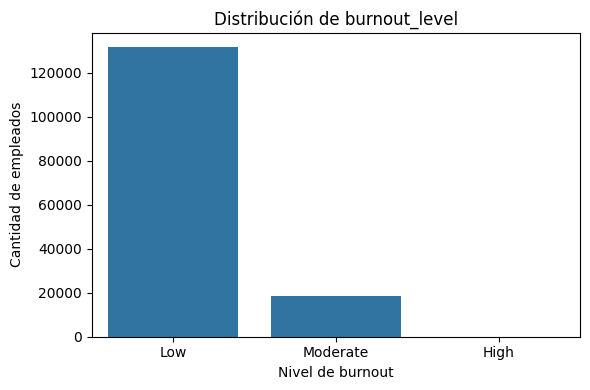

burnout_level
Low         87.7%
Moderate    12.2%
High         0.0%
Name: proportion, dtype: object


In [7]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='burnout_level', order=df['burnout_level'].value_counts().index)
plt.title('Distribución de burnout_level')
plt.xlabel('Nivel de burnout')
plt.ylabel('Cantidad de empleados')
plt.tight_layout()
plt.show()

print(df['burnout_level'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

Se observa un fuerte desbalance de clases: la categoría Low concentra aproximadamente el 88% de los registros, mientras que High representa una fracción muy pequeña.

Este desbalance puede afectar negativamente el desempeño del modelo, ya que los algoritmos tienden a favorecer la clase mayoritaria. Por este motivo, se decide reformular el problema como clasificación binaria, agrupando Moderate y High en una única clase de riesgo (burnout_risk = 1).

## 4.2  Relación con variables clave y burnout



Relación entre estrés y burnout

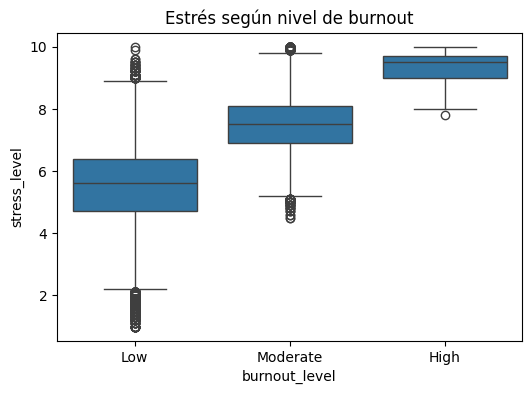

In [26]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="burnout_level", y="stress_level")
plt.title("Estrés según nivel de burnout")
plt.show()

Estrés: presenta la separación más pronunciada entre grupos, lo que sugiere que es el predictor individual más relevante.

Relación entre horas trabajadas y burnout

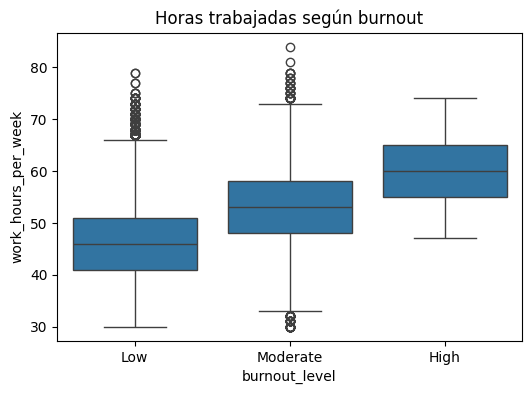

In [27]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="burnout_level", y="work_hours_per_week")
plt.title("Horas trabajadas según burnout")
plt.show()

Horas trabajadas: la tendencia es consistente (más horas, mayor burnout), aunque la diferencia entre grupos no es tan marcada.

Relación entre sueño y burnout

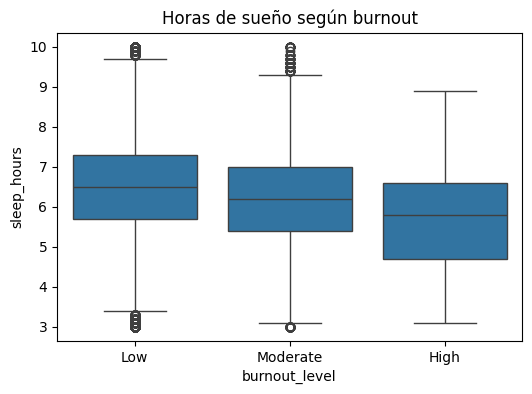

In [28]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="burnout_level", y="sleep_hours")
plt.title("Horas de sueño según burnout")
plt.show()

Horas de sueño: la diferencia entre Low y High es menor de lo esperado, aunque la dirección de la relación se mantiene.

## 4.3. Correlaciones

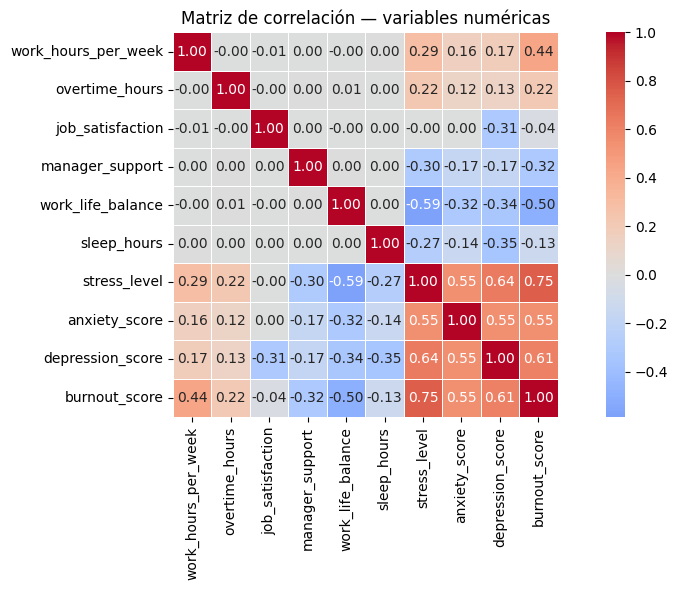

In [29]:
cols_corr = [
    'work_hours_per_week', 'overtime_hours', 'job_satisfaction',
    'manager_support', 'work_life_balance', 'sleep_hours',
    'stress_level', 'anxiety_score', 'depression_score', 'burnout_score'
]

corr = df[cols_corr].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True)
plt.title('Matriz de correlación — variables numéricas')
plt.tight_layout()
plt.show()



Las variables de salud mental (stress_level, anxiety_score, depression_score) presentan alta correlación positiva con burnout_score. Variables como work_life_balance y sleep_hours muestran correlación negativa, comportándose como factores protectores.


## 4.4 Cardinalidad de variables categóricas y valores nulos

In [30]:
print(f'Total de valores nulos: {df.isnull().sum().sum()}\n')

for col in ['gender', 'job_role', 'company_size', 'work_mode']:
    print(f'{col}: {df[col].nunique()} categorías — {df[col].unique().tolist()}')

Total de valores nulos: 0

gender: 3 categorías — ['Female', 'Male', 'Non-binary']
job_role: 8 categorías — ['Backend Developer', 'Frontend Developer', 'DevOps', 'Data Scientist', 'Software Engineer', 'Product Manager', 'QA Engineer', 'ML Engineer']
company_size: 4 categorías — ['Large', 'Mid-size', 'MNC', 'Startup']
work_mode: 3 categorías — ['Hybrid', 'Remote', 'Onsite']


# 5. Modelado con PySpark y MLFlow

En esta sección se construye el pipeline de procesamiento y se entrenan los modelos de clasificación base. El uso de pipelines garantiza la reproducibilidad y facilita la integración con MLflow.

## 5.1 Inicialización de Spark

In [8]:
spark = SparkSession.builder \
    .appName('TP_BigData_Burnout') \
    .getOrCreate()

spark.sparkContext.setLogLevel('ERROR')
print(spark)

26/04/04 17:09:56 WARN Utils: Your hostname, MacBook-Air-40.local resolves to a loopback address: 127.0.0.1; using 192.168.0.7 instead (on interface en0)
26/04/04 17:09:56 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/04 17:09:57 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## 5.2 División del dataset y preparación de Spark

Se realiza la división del dataset antes de la conversión a Spark para asegurar un aislamiento total del conjunto de prueba. Se convierte el DataFrame de Pandas a Spark y se crea la variable binaria burnout_risk. Luego se eliminan burnout_level y burnout_score para evitar data leakage.

In [9]:
df_train_pd, df_test_pd = train_test_split(df, test_size=0.2, random_state=42)

train_df = spark.createDataFrame(df_train_pd)
test_df = spark.createDataFrame(df_test_pd)

def prepare_target(sdf):
    sdf = sdf.withColumn(
        'burnout_risk',
        F.when(F.col('burnout_level').isin('Moderate', 'High'), 1).otherwise(0)
    )
    return sdf.drop('burnout_level', 'burnout_score')

train_df = prepare_target(train_df)
test_df = prepare_target(test_df)

print(f"Train count: {train_df.count()}")
print(f"Test count: {test_df.count()}")
train_df.printSchema()

Train count: 120000
Test count: 30000
root
 |-- age: long (nullable = true)
 |-- gender: string (nullable = true)
 |-- job_role: string (nullable = true)
 |-- experience_years: double (nullable = true)
 |-- company_size: string (nullable = true)
 |-- work_mode: string (nullable = true)
 |-- work_hours_per_week: double (nullable = true)
 |-- overtime_hours: double (nullable = true)
 |-- meetings_per_day: double (nullable = true)
 |-- deadlines_missed: long (nullable = true)
 |-- job_satisfaction: double (nullable = true)
 |-- manager_support: double (nullable = true)
 |-- work_life_balance: double (nullable = true)
 |-- sleep_hours: double (nullable = true)
 |-- physical_activity_days: long (nullable = true)
 |-- screen_time_hours: double (nullable = true)
 |-- caffeine_intake: long (nullable = true)
 |-- social_support_score: double (nullable = true)
 |-- has_therapy: long (nullable = true)
 |-- stress_level: double (nullable = true)
 |-- anxiety_score: double (nullable = true)
 |-- de

## 5.3 Pipeline de preprocesamiento

El pipeline se entrena (fit) únicamente con los datos de entrenamiento. Esto previene el data leakage, garantizando que el preprocesamiento no utilice información del conjunto de prueba.

In [10]:
categorical_cols = ["gender", "job_role", "company_size", "work_mode"]
numeric_cols = [
    "age", "experience_years", "work_hours_per_week", "overtime_hours",
    "meetings_per_day", "deadlines_missed", "job_satisfaction",
    "manager_support", "work_life_balance", "sleep_hours",
    "physical_activity_days", "screen_time_hours", "caffeine_intake",
    "social_support_score", "has_therapy", "stress_level",
    "anxiety_score", "depression_score", "seeks_professional_help"
]

indexers = [
    StringIndexer(inputCol=col, outputCol=f"{col}_idx", handleInvalid="keep")
    for col in categorical_cols
]

encoders = [
    OneHotEncoder(inputCol=f"{col}_idx", outputCol=f"{col}_ohe")
    for col in categorical_cols
]

feature_cols = numeric_cols + [f"{col}_ohe" for col in categorical_cols]

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features"
)

pipeline = Pipeline(stages=indexers + encoders + [assembler])

pipeline_model = pipeline.fit(train_df)

train_df = pipeline_model.transform(train_df)
test_df = pipeline_model.transform(test_df)

## 5.4 Registro de experimentos con MLflow

Usamos MLflow para registrar los dos modelos y poder comparar métricas desde la UI. Además de AUC logueamos también F1 y los parámetros principales de cada modelo.

In [11]:
# Experimento separado para mantener los runs de HPO
# independientes de los modelos base
mlflow.set_experiment('TP_BigData_Burnout_HPO')
mlflow.end_run()

print('Experimento MLflow configurado: TP_BigData_Burnout_HPO')

2026/04/04 17:15:04 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/04/04 17:15:04 INFO mlflow.store.db.utils: Updating database tables
INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
INFO  [alembic.runtime.migration] Will assume non-transactional DDL.
INFO  [alembic.runtime.migration] Running upgrade  -> 451aebb31d03, add metric step
INFO  [alembic.runtime.migration] Running upgrade 451aebb31d03 -> 90e64c465722, migrate user column to tags
INFO  [alembic.runtime.migration] Running upgrade 90e64c465722 -> 181f10493468, allow nulls for metric values
INFO  [alembic.runtime.migration] Running upgrade 181f10493468 -> df50e92ffc5e, Add Experiment Tags Table
INFO  [alembic.runtime.migration] Running upgrade df50e92ffc5e -> 7ac759974ad8, Update run tags with larger limit
INFO  [alembic.runtime.migration] Running upgrade 7ac759974ad8 -> 89d4b8295536, create latest metrics table
INFO  [89d4b8295536_create_latest_metrics_table_py] Migration complete!
INFO  

Experimento MLflow configurado: TP_BigData_Burnout_HPO


# 6. Búsqueda de hiperparámetros con Optuna + MLflow Tracking

En esta sección se optimizan los dos modelos elegidos del trabajo:
- **Logistic Regression**
- **Random Forest**

Para cada trial de Optuna se registran:
- hiperparámetros probados
- métricas de desempeño (**AUC** y **F1**)
- nombre del modelo

Todo queda guardado en **MLflow Tracking**, así que después se puede comparar fácilmente desde la UI.


## 6.2 Optimización — Regresión Logística

| Hiperparámetro | Descripción | Rango |
|---|---|---|
| `regParam` | Fuerza de regularización | [1e-4, 10] log-escala |
| `elasticNetParam` | Balance L1/L2 (0=Ridge, 1=Lasso) | [0.0, 1.0] |
| `maxIter` | Iteraciones máximas | {50, 100, ..., 300} |

Definimos las métricas que vamos a loggear

In [12]:
evaluator_auc = BinaryClassificationEvaluator(
    labelCol='burnout_risk', metricName='areaUnderROC')
evaluator_f1 = MulticlassClassificationEvaluator(
    labelCol='burnout_risk', metricName='f1')

In [13]:
def objective_lr(trial):
    reg_param   = trial.suggest_float('regParam',         1e-4, 10.0, log=True)
    elastic_net = trial.suggest_float('elasticNetParam',  0.0,  1.0)
    max_iter    = trial.suggest_int('maxIter',            50,   300,  step=50)

    clf = LogisticRegression(
        featuresCol='features', labelCol='burnout_risk',
        regParam=reg_param, elasticNetParam=elastic_net, maxIter=max_iter
    )

    with mlflow.start_run(run_name=f'LR_trial_{trial.number:02d}', nested=True):
        mlflow.log_param('model',           'LogisticRegression')
        mlflow.log_param('regParam',        round(reg_param, 6))
        mlflow.log_param('elasticNetParam', round(elastic_net, 4))
        mlflow.log_param('maxIter',         max_iter)

        model = clf.fit(train_df)
        preds = model.transform(test_df)
        
        auc   = evaluator_auc.evaluate(preds)
        f1    = evaluator_f1.evaluate(preds)

        mlflow.log_metric('AUC', auc)
        mlflow.log_metric('F1',  f1)

    return auc


with mlflow.start_run(run_name='HPO_LogisticRegression'):
    study_lr = optuna.create_study(
        direction='maximize',
        study_name='LR_burnout',
        sampler=optuna.samplers.TPESampler(seed=42)
    )
    study_lr.optimize(objective_lr, n_trials=20, show_progress_bar=True)

    best_lr = study_lr.best_trial
    mlflow.log_metric('best_AUC', best_lr.value)
    for k, v in best_lr.params.items():
        mlflow.log_param(f'best_{k}', v)

print(f'\n Mejor trial LR #{best_lr.number} — AUC: {best_lr.value:.4f}')
print(f'   Parámetros: {best_lr.params}')

Best trial: 5. Best value: 0.963888: 100%|██████████| 20/20 [03:13<00:00,  9.65s/it]


 Mejor trial LR #5 — AUC: 0.9639
   Parámetros: {'regParam': 0.0008260808399079611, 'elasticNetParam': 0.3042422429595377, 'maxIter': 200}


## 6.3 Optimización — Random Forest

| Hiperparámetro | Descripción | Rango |
|---|---|---|
| `numTrees` | Número de árboles | {20, 40, ..., 100} |
| `maxDepth` | Profundidad máxima | [3, 15] |
| `minInfoGain` | Ganancia mínima para split | [0.0, 0.1] |

In [14]:
def objective_rf(trial):
    num_trees     = trial.suggest_int('numTrees',     25,  100, step=20)
    max_depth     = trial.suggest_int('maxDepth',      3,   15)
    min_info_gain = trial.suggest_float('minInfoGain', 0.0, 0.1)

    clf = RandomForestClassifier(
        featuresCol='features', 
        labelCol='burnout_risk',
        numTrees=num_trees, 
        maxDepth=max_depth,
        minInfoGain=min_info_gain, 
        seed=42
    )

    with mlflow.start_run(run_name=f'RF_trial_{trial.number:02d}', nested=True):
        mlflow.log_param('model',       'RandomForest')
        mlflow.log_param('numTrees',    num_trees)
        mlflow.log_param('maxDepth',    max_depth)
        mlflow.log_param('minInfoGain', round(min_info_gain, 5))

        model = clf.fit(train_df)
        preds = model.transform(test_df)
        
        auc = evaluator_auc.evaluate(preds)
        f1  = evaluator_f1.evaluate(preds)

        mlflow.log_metric('AUC', auc)
        mlflow.log_metric('F1',  f1)

    return auc

with mlflow.start_run(run_name='HPO_RandomForest'):
    study_rf = optuna.create_study(
        direction='maximize',
        study_name='RF_burnout',
        sampler=optuna.samplers.TPESampler(seed=42)
    )
    study_rf.optimize(objective_rf, n_trials=20, show_progress_bar=True)

    best_rf = study_rf.best_trial
    mlflow.log_metric('best_AUC', best_rf.value)
    for k, v in best_rf.params.items():
        mlflow.log_param(f'best_{k}', v)

print(f'\n Mejor trial RF #{best_rf.number} — AUC: {best_rf.value:.4f}')
print(f'   Parámetros: {best_rf.params}')

  0%|          | 0/20 [00:00<?, ?it/s]/Users/vickyreppucci/Desktop/MCD/MLOps/Grupo-4--TP-BigData-Burnout/venv/lib/python3.9/site-packages/optuna/distributions.py:700: UserWarning: The distribution is specified by [25, 100] and step=20, but the range is not divisible by `step`. It will be replaced by [25, 85].
  warnings.warn(
Best trial: 15. Best value: 0.949417: 100%|██████████| 20/20 [03:41<00:00, 11.09s/it]


 Mejor trial RF #15 — AUC: 0.9494
   Parámetros: {'numTrees': 65, 'maxDepth': 11, 'minInfoGain': 0.0007819996906833348}


## 6.4 Selección del mejor modelo

In [16]:
print('=== Resumen HPO ===')
print(f'  Logistic Regression — mejor AUC: {best_lr.value:.4f} (trial #{best_lr.number})')
print(f'  Random Forest       — mejor AUC: {best_rf.value:.4f} (trial #{best_rf.number})')

if best_lr.value >= best_rf.value:
    BEST_MODEL_NAME = 'LogisticRegression'
    BEST_PARAMS     = best_lr.params
    BEST_AUC        = best_lr.value
    BEST_STUDY      = study_lr
else:
    BEST_MODEL_NAME = 'RandomForest'
    BEST_PARAMS     = best_rf.params
    BEST_AUC        = best_rf.value
    BEST_STUDY      = study_rf

print(f'\n Modelo seleccionado: {BEST_MODEL_NAME} (AUC = {BEST_AUC:.4f})')
print(f'   Hiperparámetros: {BEST_PARAMS}')

=== Resumen HPO ===
  Logistic Regression — mejor AUC: 0.9639 (trial #5)
  Random Forest       — mejor AUC: 0.9494 (trial #15)

 Modelo seleccionado: LogisticRegression (AUC = 0.9639)
   Hiperparámetros: {'regParam': 0.0008260808399079611, 'elasticNetParam': 0.3042422429595377, 'maxIter': 200}


## 6.5 Visualización de los experimentos de HPO

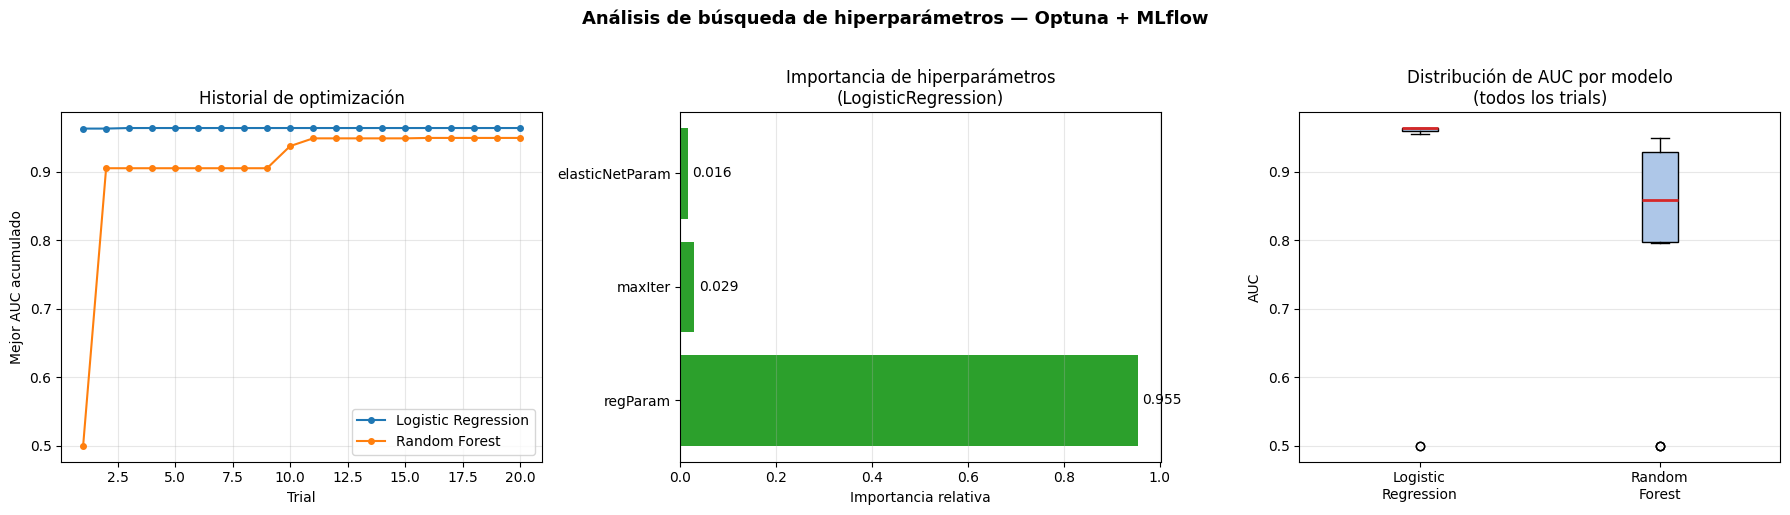

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico 1: Historial de optimización
ax = axes[0]
for study, label, color in [
    (study_lr, 'Logistic Regression', '#1f77b4'),
    (study_rf, 'Random Forest',       '#ff7f0e')
]:
    best_so_far, current_best = [], 0
    for t in study.trials:
        if t.value and t.value > current_best:
            current_best = t.value
        best_so_far.append(current_best)
    ax.plot(range(1, len(best_so_far) + 1), best_so_far,
            marker='o', markersize=4, label=label, color=color)
ax.set_title('Historial de optimización')
ax.set_xlabel('Trial')
ax.set_ylabel('Mejor AUC acumulado')
ax.legend()
ax.grid(True, alpha=0.3)

# Gráfico 2: Importancia de hiperparámetros
ax = axes[1]
try:
    importances = optuna.importance.get_param_importances(BEST_STUDY)
    bars = ax.barh(list(importances.keys()), list(importances.values()), color='#2ca02c')
    ax.bar_label(bars, fmt='%.3f', padding=3)
    ax.set_title(f'Importancia de hiperparámetros\n({BEST_MODEL_NAME})')
    ax.set_xlabel('Importancia relativa')
    ax.grid(True, axis='x', alpha=0.3)
except Exception as e:
    ax.text(0.5, 0.5, f'No disponible\n{e}', ha='center', va='center', transform=ax.transAxes)

# Gráfico 3: Distribución de AUC por modelo
ax = axes[2]
auc_lr_vals = [t.value for t in study_lr.trials if t.value is not None]
auc_rf_vals = [t.value for t in study_rf.trials if t.value is not None]
ax.boxplot([auc_lr_vals, auc_rf_vals],
           labels=['Logistic\nRegression', 'Random\nForest'],
           patch_artist=True,
           boxprops=dict(facecolor='#aec7e8'),
           medianprops=dict(color='#d62728', linewidth=2))
ax.set_title('Distribución de AUC por modelo\n(todos los trials)')
ax.set_ylabel('AUC')
ax.grid(True, axis='y', alpha=0.3)

plt.suptitle('Análisis de búsqueda de hiperparámetros — Optuna + MLflow',
             fontsize=13, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

## 6.6 Tabla resumen de trials

In [18]:
def study_to_df(study, model_name):
    rows = []
    for t in study.trials:
        if t.value is not None:
            row = {'modelo': model_name, 'trial': t.number, 'AUC': round(t.value, 4)}
            row.update({k: round(v, 5) if isinstance(v, float) else v
                        for k, v in t.params.items()})
            rows.append(row)
    return pd.DataFrame(rows)

df_all_trials = pd.concat(
    [study_to_df(study_lr, 'LogisticRegression'),
     study_to_df(study_rf, 'RandomForest')],
    ignore_index=True
)

print('Top 10 trials por AUC:')
display(df_all_trials.sort_values('AUC', ascending=False).head(10))

Top 10 trials por AUC:


,modelo,trial,AUC,regParam,elasticNetParam,maxIter,numTrees,maxDepth,minInfoGain
12,LogisticRegression,12,0.9639,0.00114,0.97614,250.0,NaN,NaN,NaN
2,LogisticRegression,2,0.9639,0.00020,0.86618,200.0,NaN,NaN,NaN
19,LogisticRegression,19,0.9639,0.00036,0.33422,100.0,NaN,NaN,NaN
18,LogisticRegression,18,0.9639,0.00080,0.74208,200.0,NaN,NaN,NaN
5,LogisticRegression,5,0.9639,0.00083,0.30424,200.0,NaN,NaN,NaN
7,LogisticRegression,7,0.9639,0.00050,0.29214,150.0,NaN,NaN,NaN
15,LogisticRegression,15,0.9639,0.00042,0.68989,200.0,NaN,NaN,NaN
13,LogisticRegression,13,0.9639,0.00011,0.77120,150.0,NaN,NaN,NaN
10,LogisticRegression,10,0.9639,0.00109,0.47333,300.0,NaN,NaN,NaN
11,LogisticRegression,11,0.9639,0.00011,0.56561,200.0,NaN,NaN,NaN


## 6.7 Evaluación del mejor modelo

Resultado Final (LogisticRegression): AUC = 0.9639, F1 = 0.9310


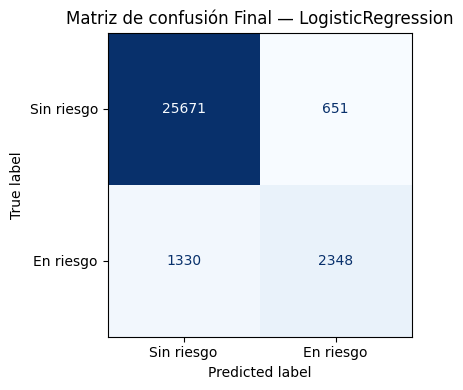

In [19]:
if BEST_MODEL_NAME == 'LogisticRegression':
    final_clf = LogisticRegression(featuresCol='features', labelCol='burnout_risk', **BEST_PARAMS)
else:
    final_clf = RandomForestClassifier(featuresCol='features', labelCol='burnout_risk', **BEST_PARAMS, seed=42)

model_final = final_clf.fit(train_df)
preds_final = model_final.transform(test_df)

final_auc = evaluator_auc.evaluate(preds_final)
final_f1  = evaluator_f1.evaluate(preds_final)

print(f"Resultado Final ({BEST_MODEL_NAME}): AUC = {final_auc:.4f}, F1 = {final_f1:.4f}")

preds_pd = preds_final.select('burnout_risk', 'prediction').toPandas()
cm       = confusion_matrix(preds_pd['burnout_risk'], preds_pd['prediction'])
disp     = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Sin riesgo', 'En riesgo'])

fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Matriz de confusión Final — {BEST_MODEL_NAME}')
plt.tight_layout()
plt.show()

## 6.8 Interpretabilidad con SHAP

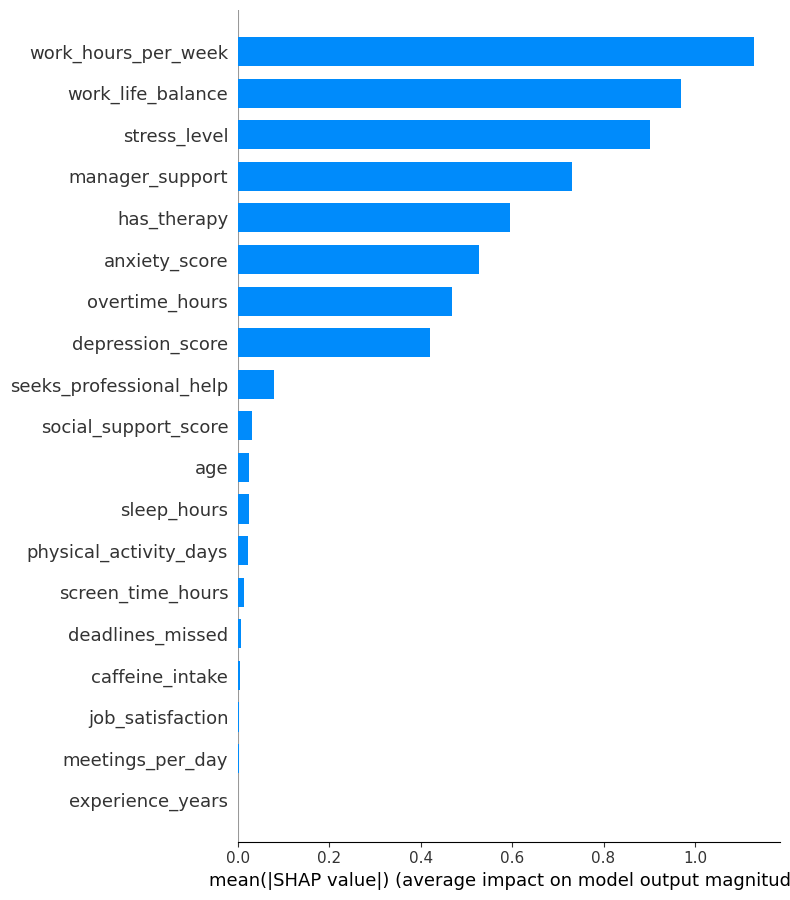

In [20]:
train_pd = train_df.select(numeric_cols + ['burnout_risk']).toPandas().dropna()
X_train  = train_pd[numeric_cols]
y_train  = train_pd['burnout_risk']

# Configurar el modelo equivalente en Scikit-Learn según el ganador
if BEST_MODEL_NAME == 'LogisticRegression':
    # Spark regParam es inversamente proporcional a C en sklearn
    c_val = 1.0 / BEST_PARAMS.get('regParam', 0.1)
    l1_ratio = BEST_PARAMS.get('elasticNetParam', 0.0)
    
    sk_model = SklearnLR(C=c_val, l1_ratio=l1_ratio, penalty='elasticnet', 
                         solver='saga', max_iter=2000)
    sk_model.fit(X_train, y_train)
    explainer = shap.LinearExplainer(sk_model, X_train)
    shap_values = explainer.shap_values(X_train)
else:
    sk_model = SklearnRF(n_estimators=BEST_PARAMS.get('numTrees', 100),
                         max_depth=BEST_PARAMS.get('maxDepth', 5),
                         min_impurity_decrease=BEST_PARAMS.get('minInfoGain', 0.0),
                         random_state=42)
    sk_model.fit(X_train, y_train)
    explainer = shap.TreeExplainer(sk_model)
    # Para RF, tomamos los valores SHAP de la clase positiva (índice 1)
    shap_values = explainer.shap_values(X_train)
    if isinstance(shap_values, list): # Depende de la versión de SHAP
        shap_values = shap_values[1]

# Visualización de importancia de variables
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_train, plot_type='bar',
                 title=f'Importancia de variables — SHAP ({BEST_MODEL_NAME} Optimizado)')

Las variables con mayor impacto son work_hours_per_week, work_life_balance y stress_level lo cual es consistente con el análisis exploratorio.

# 7. Entrenamiento final y registro del modelo para producción

Con los mejores hiperparámetros identificados por Optuna, se reentrena el modelo final sobre el dataset completo y se registra en el **MLflow Model Registry** para su versionado y posterior despliegue.

In [23]:
full_df_spark = spark.createDataFrame(df)

def prepare_target_final(sdf):
    sdf = sdf.withColumn(
        'burnout_risk',
        F.when(F.col('burnout_level').isin('Moderate', 'High'), 1).otherwise(0)
    )
    # Eliminamos las columnas que causan Data Leakage
    return sdf.drop('burnout_level', 'burnout_score')

full_df_spark = prepare_target_final(full_df_spark)

if BEST_MODEL_NAME == 'LogisticRegression':
    final_clf = LogisticRegression(
        featuresCol='features', 
        labelCol='burnout_risk',
        regParam=BEST_PARAMS['regParam'],
        elasticNetParam=BEST_PARAMS['elasticNetParam'],
        maxIter=int(BEST_PARAMS['maxIter'])
    )
else:
    final_clf = RandomForestClassifier(
        featuresCol='features', 
        labelCol='burnout_risk',
        numTrees=int(BEST_PARAMS['numTrees']),
        maxDepth=int(BEST_PARAMS['maxDepth']),
        minInfoGain=BEST_PARAMS['minInfoGain'],
        seed=42
    )

production_pipeline = Pipeline(stages=indexers + encoders + [assembler, final_clf])

print(f"Entrenando modelo de producción sobre {full_df_spark.count()} filas...")
final_production_model = production_pipeline.fit(full_df_spark)

modelo_nombre_registro = "Burnout_Production_Model_Final"

with mlflow.start_run(run_name="Full_Dataset_Production_Run") as run:
    mlflow.log_params(BEST_PARAMS)
    mlflow.log_param("total_rows", full_df_spark.count())
    
    # Registramos el PipelineModel (incluye preprocesamiento + modelo)
    mlflow.spark.log_model(
        spark_model=final_production_model,
        artifact_path="spark-model",
        registered_model_name=modelo_nombre_registro
    )
    
    run_id_final = run.info.run_id

print(f"Éxito: PipelineModel registrado como '{modelo_nombre_registro}'")
print("Este modelo ya puede ser consumido por la API recibiendo datos crudos.")

Entrenando modelo de producción sobre 150000 filas...


Éxito: PipelineModel registrado como 'Burnout_Production_Model_Final'
Este modelo ya puede ser consumido por la API recibiendo datos crudos.


Successfully registered model 'Burnout_Production_Model_Final'.
Created version '1' of model 'Burnout_Production_Model_Final'.


Generamos un dataset dummy para evaluar la API y la interfaz a través de la cual consumiremos el modelo.

In [25]:
# Corre esto en tu notebook
cols_interfaz = categorical_cols + numeric_cols
df_test_pd[cols_interfaz].head(10).to_csv(os.path.join(root_path, "data", "test_api_dataset.csv"), index=False)


# 8. Conclusiones

En este trabajo se desarrolló un pipeline completo de Machine Learning para la predicción de riesgo de burnout en empleados del sector tecnológico, utilizando PySpark como framework de procesamiento distribuido y MLflow para la gestión de experimentos y versionado de modelos.

## Principales hallazgos

- En el análisis exploratorio se identificó que puntuaciones altas en ansiedad y depresión, junto con una baja calidad de sueño, están estrechamente vinculadas al riesgo detectado.
- El análisis de importancia de características (mediante SHAP) confirmó que el nivel de estrés es el factor con mayor impacto, seguido por las horas trabajadas por semana y el balance vida-trabajo.
- Se entrenaron y compararon dos modelos. La **Regresión Logística** fue seleccionada como modelo final por su mejor desempeño (AUC y F1) y mayor interpretabilidad.
- La búsqueda de hiperparámetros con **Optuna** (20 trials por modelo, algoritmo TPE) permitió obtener las mejores métricas posibles, con todos los experimentos trazados en MLflow.
- El modelo final fue registrado en el **MLflow Model Registry**

## Limitaciones y trabajo futuro

- Aplicar técnicas de balanceo de clases (SMOTE, `class_weight`) para mejorar la detección de la clase minoritaria.
- Optimizar el umbral de decisión más allá del valor por defecto de 0.5, priorizando la reducción de falsos negativos.
